# CoexpressDeconvolve
Multi-slice Visium spatial transcriptomics deconvolution to in-silico single cells.

Pass `visium_path` as a string (single slice) or a dict `{name: path}` for multiple slices.
Per-slice parameters (`min_umi`, `anchor_mean_factor`, `low_slice_quality`) accept either a scalar (broadcast to all slices) or a dict keyed by slice name.

In [1]:
# %pip install h5py tqdm umap-learn

In [2]:
import codeconv
import os

codeconv.set_seed(42)

codeconv: random seed set to 42


In [3]:
# Single slice:
visium_path = "./Synthetic Visium"
# Multi-slice:
#   visium_path = {"Slice 1": "./path/A", "Slice 2": "./path/B"}
# Or list (slice names auto-derived from os.path.basename):
#   visium_path = ["./samples/Slice 1", "./samples/Slice 2"]

output_folder = "."
config_path   = "codeconv_config.json"
species       = "hs"  # "hs" | "mm" | "other"

## Step 1: Load Visium data


Step 1 [Synthetic Visium]: loading from ./Synthetic Visium
   > h5 file: ./Synthetic Visium/filtered_feature_bc_matrix.h5
   median UMI/spot: 113888   mean: 123892   1st pct: 2614


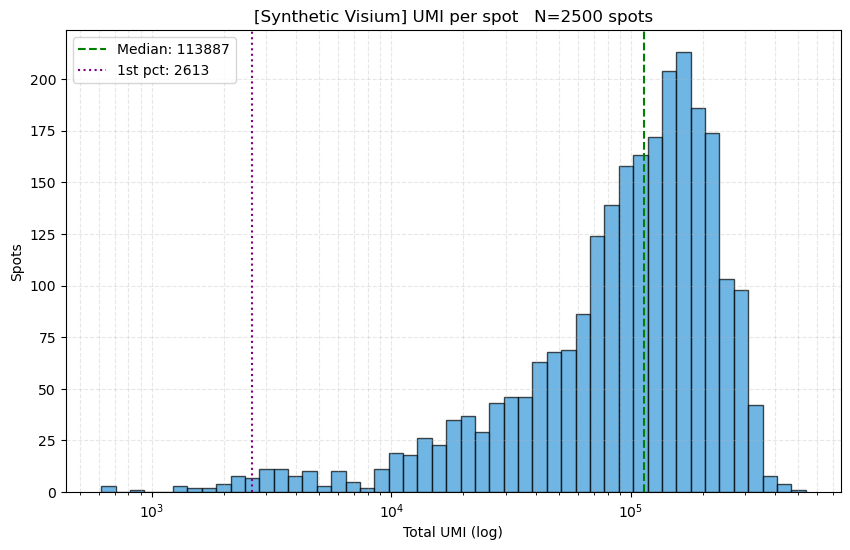


Step 1 done in 1.05s   1 slice(s) loaded.


In [4]:
slices = codeconv.step1_acquisition_and_anchoring(visium_path)

## Step 2: Cell Density Estimation
Adjust `anchor_mean_factor` so that the red line in the calibration plot aligns with the first non-zero peak. Use the dict form for per-slice overrides.


Step 2 [Synthetic Visium]: Hybrid Calibration (alpha=0.6, factor=0.7)


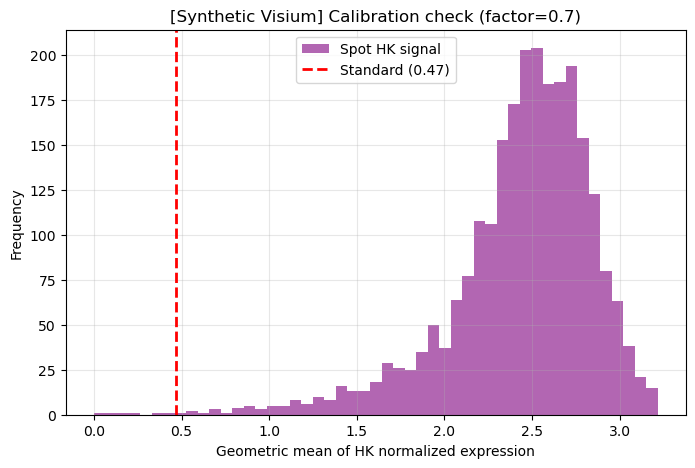

   empty spots: 47/2500 (1.9%)   filtered by UMI: 0


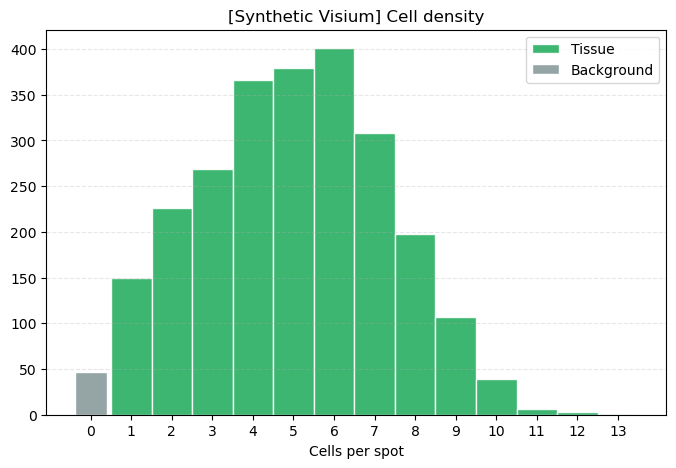

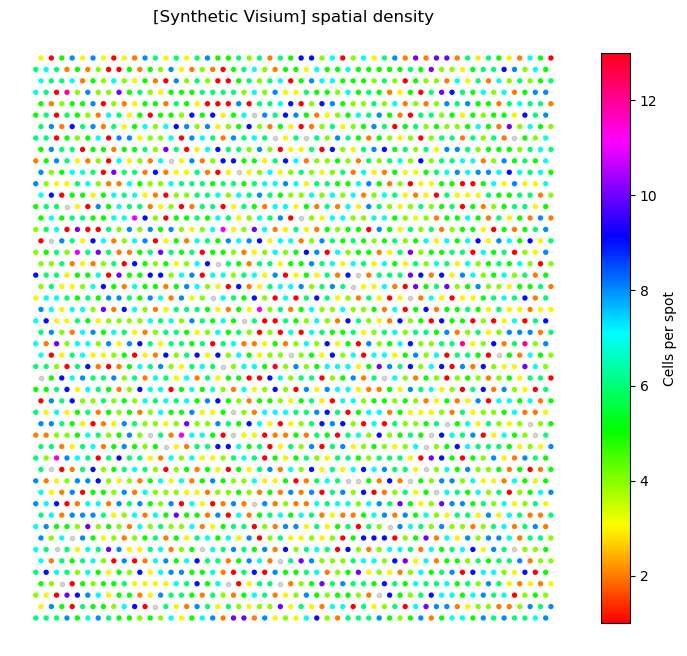

   total cells on slide: 12382

Step 2 done in 0.22s


In [5]:
slices = codeconv.step2_estimate_cell_density(
    slices, config_path, species,
    min_umi=0,
    # min_umi = {"Slice 1": 900, "Slice 2": 924},
    anchor_mean_factor=0.7,
    # anchor_mean_factor = {"Slice 1": 0.9, "Slice 2": 0.85},
    low_slice_quality=False,
    # low_slice_quality = {"Slice 1": False, "Slice 2": True},
    colormap='hsv',
)

# Sidestep - Benchmark Predicted vs True Cell counts

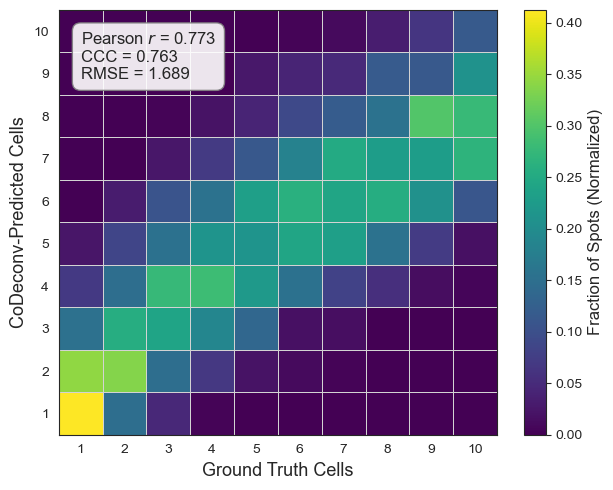

Stats saved to CoexpressDeconvolve_CellCount_NormalizedGrid_Viridis.png
Pearson r: 0.773, CCC: 0.763, RMSE: 1.689


Exception ignored in: <function ResourceTracker.__del__ at 0x103bd5800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106f19800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1047e1800>
Traceback (most recent call last

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.metrics import mean_squared_error
import matplotlib.lines as mlines

# 1. Metric Helper: CCC
def calculate_ccc(x, y):
    cor = np.corrcoef(x, y)[0][1]
    mean_x, mean_y = np.mean(x), np.mean(y)
    var_x, var_y = np.var(x), np.var(y)
    sd_x, sd_y = np.std(x), np.std(y)
    numerator = 2 * cor * sd_x * sd_y
    denominator = var_x + var_y + (mean_x - mean_y)**2
    return numerator / denominator

# 2. Extract Predictions
pred_list = []
for name, sd in slices.items():
    df_slice = pd.DataFrame({
        'Spot': sd.barcodes if hasattr(sd, 'barcodes') else sd.obs_names,
        'Predicted_Cells': sd.n_cells
    })
    pred_list.append(df_slice)

all_preds = pd.concat(pred_list).drop_duplicates('Spot')

# 3. Load Ground Truth and Merge
gt = pd.read_csv("ground_truth_counts.csv")

comparison_df = pd.merge(gt, all_preds, on='Spot')
valid_df = comparison_df[comparison_df['Predicted_Cells'] > 0].copy()

# 4. Calculate Stats 
x_true = valid_df['Total_Cells'].values
y_pred = valid_df['Predicted_Cells'].values

r_val, _ = pearsonr(x_true, y_pred)
ccc_val = calculate_ccc(x_true, y_pred)
rmse_val = np.sqrt(mean_squared_error(x_true, y_pred))

# Calculate Linear Regression for the Pearson Line
slope, intercept, _, _, _ = linregress(x_true, y_pred)

# 5. Generate Plot (Normalized 2D Squares - Viridis)
sns.set_style("white") # Keep white to avoid grid clashes
fig, ax = plt.subplots(figsize=(6.3, 5))

# 1. Create the grid manually
bins = np.arange(0.5, 11.5, 1)
H, xedges, yedges = np.histogram2d(x_true, y_pred, bins=(bins, bins))

# 2. Normalize by Ground Truth (Columns)
H_sums = H.sum(axis=1, keepdims=True)
H_norm = np.divide(H, H_sums, out=np.zeros_like(H), where=H_sums!=0)

# 3. Plot the Squares
mesh = ax.pcolormesh(
    xedges, 
    yedges, 
    H_norm.T, 
    cmap='viridis', # Switched back to Viridis
    edgecolors='lightgray', 
    linewidth=0.5
)

# 4. Add Colorbar
cb = fig.colorbar(mesh, ax=ax)
cb.set_label('Fraction of Spots (Normalized)', fontsize=12)

# 5. Add Stats Text Box (Replacing the Legend)
stats_text = (f'Pearson $r$ = {r_val:.3f}\n'
              f'CCC = {ccc_val:.3f}\n'
              f'RMSE = {rmse_val:.3f}')

# Place a clean white text box in the upper left corner
text_props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=text_props)

# 6. Clean up Axes
ax.set_xlim(0.5, 10.5)
ax.set_ylim(0.5, 10.5)
ax.set_xticks(np.arange(1, 11, 1))
ax.set_yticks(np.arange(1, 11, 1))

ax.set_xlabel("Ground Truth Cells", fontsize=13)
ax.set_ylabel("CoDeconv-Predicted Cells", fontsize=13)

plt.tight_layout()
plt.savefig("CoexpressDeconvolve_CellCount_NormalizedGrid_Viridis.png", dpi=600)
plt.show()

print(f"Stats saved to CoexpressDeconvolve_CellCount_NormalizedGrid_Viridis.png")
print(f"Pearson r: {r_val:.3f}, CCC: {ccc_val:.3f}, RMSE: {rmse_val:.3f}")

## Step 3: Noise Filter and Joint HVG selection
Per-slice noise gene removal, intersection across slices, then HVG selection on the concatenated intersected matrix.

Step 3: noise filter (species=hs)
   regex: ^MT-|^RP[SL][0-9]+|^LINC|^MIR|^AC[0-9]+
   [Synthetic Visium] removed 10444 noise genes; kept 26157

Step 3: gene set size = 26157
Step 3: presence filter [0.05, 0.95] (any across slices)
   [Synthetic Visium] presence pass: 14139/26157
   combined: 14139/26157 candidate genes after filter
Step 3: selecting top 3000 overdispersed genes from 14139 candidates...


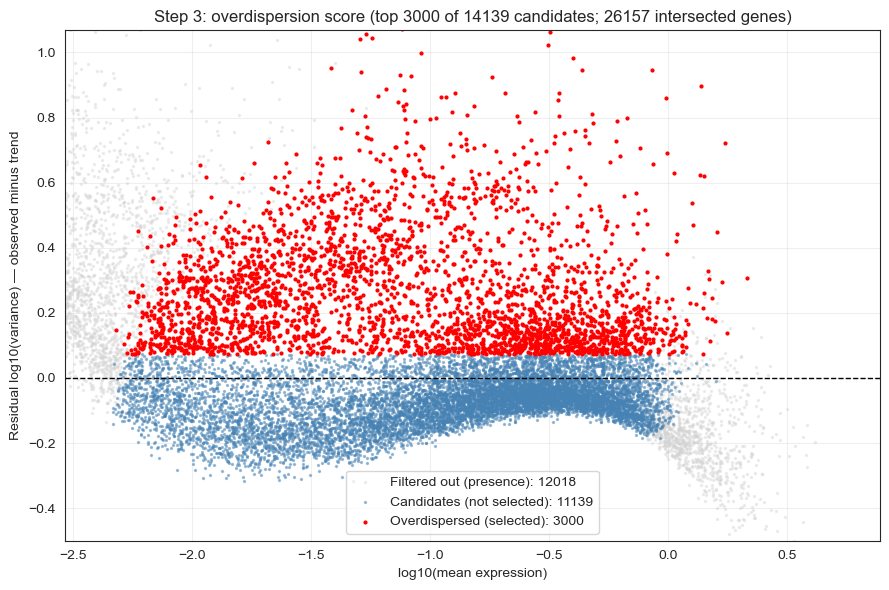

Step 3 done in 1.17s   joint overdispersed-gene matrix: (2500, 3000)


In [7]:
hvg_pack = codeconv.step3_feature_selection(
    slices, config_path, species,
    n_hvg=3000, 
) 

In [8]:
hvg_df = pd.DataFrame({'hvg_names': hvg_pack.hvg_names})
hvg_df.to_csv('fixed_hvgs.csv', index=False, header=False)

print(f"Saved {len(hvg_pack.hvg_names)} HVGs.")

Saved 3000 HVGs.


## Step 4: Joint Gene Co-expression Manifold
ICA + UMAP on the joint intersected gene matrix.

Step 4: building gene manifold over 26157 genes (single-slice native order)...
   FastICA n_components=30
   UMAP cosine projection


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


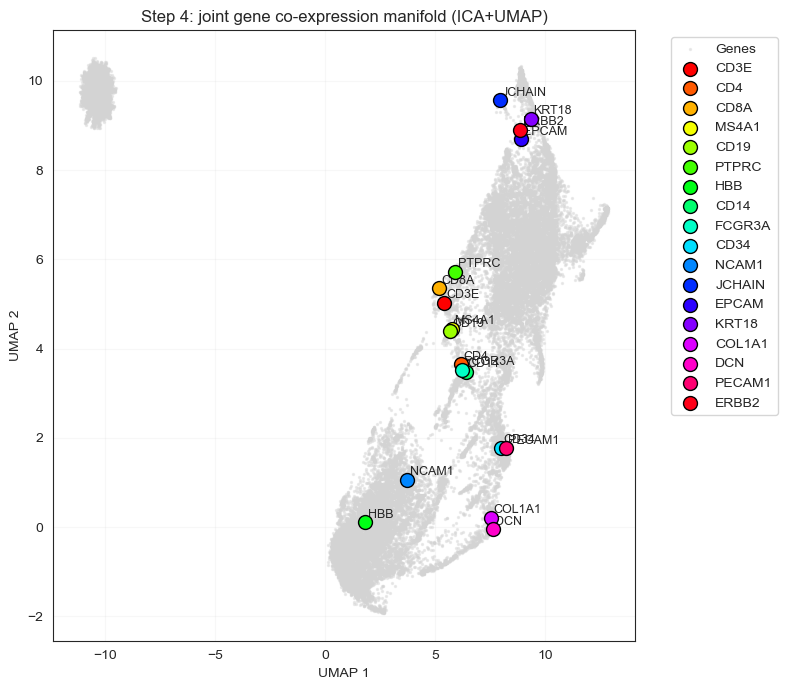

Step 4 done in 51.26s


In [9]:
manifold = codeconv.step4_gene_manifold(
    slices, hvg_pack, config_path,
    n_components=30,
)

## Step 5: K topic sweep
One sweep per slice plus a joint sweep. Inspect the overlaid line plot and the relative-perplexity heatmap before choosing `SELECTED_K` for step 6.

If per-slice elbows wildly disagree with the joint elbow, slices may be biologically heterogeneous and per-slice topics may align poorly.

Step 5 [Synthetic Visium]: full 2500 spots
   train/test split: 1750/750 (0.70/0.30)


LDA sweep [Synthetic Visium]:   0%|          | 0/8 [00:00<?, ?it/s]

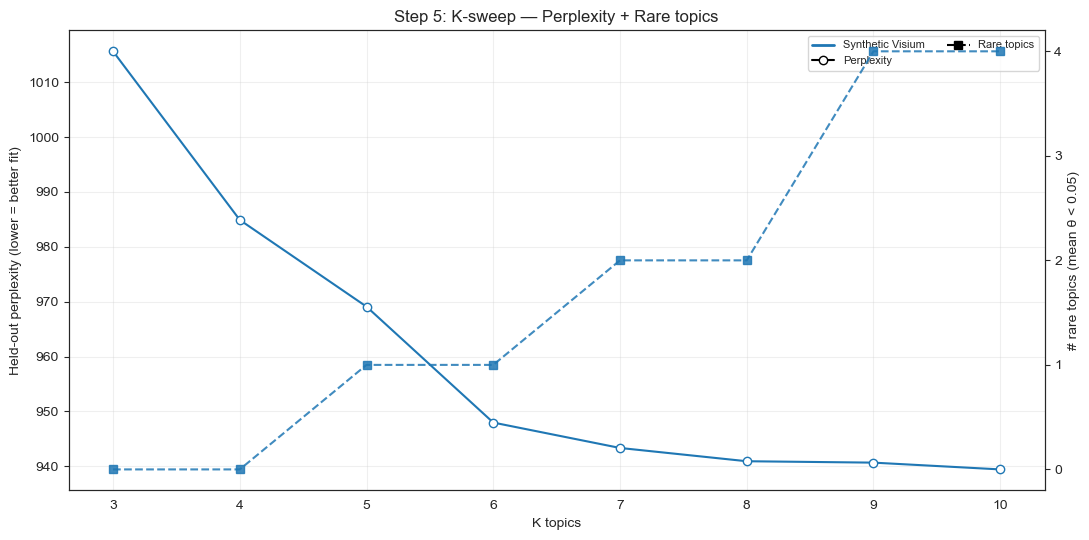


Step 5 done in 44.44s


KSweepResult(targets=['Synthetic Visium'], K=3..10)

In [10]:
codeconv.step5_ksweep(
    hvg_pack,
    min_k=3, max_k=10,
    perc_rare_thresh = 0.05,
)

## Step 6: per-slice LDA, alignment, consensus beta, projection
Fits LDA per slice, aligns topics across slices via Hungarian matching on cosine similarity of betas, builds a mean-consensus beta, refits per-slice theta against the frozen consensus beta via variational E-step, and projects consensus topics to each slice's full cleaned gene list.

In [11]:
SELECTED_K = 6

model = codeconv.step6_final_deconvolution(
    slices, hvg_pack, manifold,
    n_topics=SELECTED_K,
    k_neighbors=3,
)

print('Top markers per consensus topic:')
display(model.qc_df)

Step 6: LDA fit, K=6   (1 slice, n_seeds=1)
   [Synthetic Visium] LDA on 2500 spots (single seed)
   [Synthetic Visium] theta (2500, 6)
Step 6: projecting latent topics using UMAP manifold topology
   [Synthetic Visium] beta_final (6, 26157)
Step 6 done in 59.62s
Top markers per consensus topic:


,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,SELP,TM4SF4,C1QB,IGLC2,CHAD,CDCA3
1,COL1A2,MMP10,C1QC,IGHG1,CPB1,PARPBP
2,APLNR,ABCC5-AS1,TREM2,DERL3,IRS1,MZT1
3,CCDC80,ST7-OT4,ADAP2,ATF4,SCGB2A2,ARHGEF39
4,COL6A2,TRIM31-AS1,EPHB2,UBE2J1,FAM3B,AURKB
5,PTGDS,AP003469.2,IL1B,IGHG3,ASB13,TOP2A
6,CCL14,AP001059.2,CCL4L2,IGKC,CLRN1-AS1,CKAP2L
7,IGFBP7,AP001010.1,GPR34,IGHGP,SCGB1D2,HIST1H1B
8,BICC1,AL592211.1,LILRB4,IGHM,KIF5C,UBE2C
9,SPARC,AL390294.1,HCK,IGHA2,GREB1,RRM2


## Step 7: Sampling Engine
Generates in-silico single cells per slice. Threshold-and-renormalize on `min_topic_percentage` is always applied (default 0.05 from config). `low_slice_quality=True` per slice additionally enforces a topic-rescue inflate so every surviving topic gets at least one cell.

In [12]:
cells = codeconv.step7_sampling_engine(
    slices, model, config_path, species,
    low_slice_quality=False,
    # low_slice_quality = {"Slice 1": False, "Slice 2": True},
    min_topic_percentage=0.00, 
)


Step 7 [Synthetic Visium]: sampling   low_q=False   min_pct=0.0


[Synthetic Visium] cells:   0%|          | 0/2500 [00:00<?, ?spot/s]

   [Synthetic Visium] generated 12382 cells   rescued 0 topic slots

Step 7 done in 11.47s


## Step 8 & 9: Place Cells and Export
Fibonacci-shell placement around each spot center, then per-slice export under `output_folder/slice_<name>/deconvolved/` in 10X SpaceRanger HDF5 layout. Output is ready for `Seurat::Load10X_Spatial()`.

In [13]:
codeconv.step8_geometry_and_placement(cells, slices)
codeconv.step9_export_results(cells, slices, output_folder)

Step 8 [Synthetic Visium]: placed 12382 cells
Step 8 done in 0.05s
Step 9 [Synthetic Visium]: writing ./slice_Synthetic Visium/deconvolved/filtered_feature_bc_matrix.h5
   [Synthetic Visium] cells=12382   genes=26157

Step 9 done in 0.50s   exports ready for Seurat::Load10X_Spatial()
